# 1. Environment Setup

In [2]:
import sys 
import subprocess
import pkgutil


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'datasets': 'datasets',
    'pyarrow': 'pyarrow',
    'sklearn': 'scikit-learn',
    'tqdm': 'tqdm',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
}

print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

All dependencies already installed.



In [3]:
# Import Core Libraries
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA        

In [15]:
# # GPU Detection
# try:
#     import torch
#     cuda_available = torch.cuda.is_available()
#     if cuda_available:
#         gpu_name = torch.cuda.get_device_name(0)
#         print(f"GPU Detected: {gpu_name}")
#         DEVICE = "CUDA"
#     else:
#         print("GPU not available. Using CPU")
#         DEVICE = "CPU"
# except ImportError:
#     print("PyTorch not installed. Using CPU for analysis.")
#     DEVICE = "CPU"

In [11]:
DIR = "../data/processed/"
SOURCE_OF_TRUTH_FILE_PARQUET = os.path.join(DIR, "source_of_truth.parquet")
SAMPLED_PARQUET = os.path.join(DIR, "amazon_reviews_s10.parquet")
SAMPLED_CSV = os.path.join(DIR, "amazon_reviews_s10.csv")
# SAMPLE_SIZE = 15_000_000 # Was not used due to network issues in streaming
RANDOM_STATE = 42

# 2. Load the Dataset

In [ ]:
# CONFIGURATION
# SAMPLE_SIZE = 15_000_000 # Was not used due to network issues in streaming
# RANDOM_STATE = 42
REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"

print(f"Configuration:")
# print(f"  Sample Size: {SAMPLE_SIZE:,}")
print(f"  Random State: {RANDOM_STATE}")
print(f"  Source: Amazon Electronics Reviews (Hugging Face)\n")

In [ ]:
# Load Dataset
# import itertools

# print(f"Loading {SAMPLE_SIZE:,} reviews from Amazon Electronics dataset...\n")

# ds_iter = load_dataset("json", data_files=REVIEWS_URL, split="train", streaming=True)
# sample = list(tqdm(itertools.islice(ds_iter, SAMPLE_SIZE), total=SAMPLE_SIZE, desc="Streaming"))

# df = Dataset.from_list(sample).to_pandas()

ds = load_dataset("json", data_files=REVIEWS_URL, split="train")
df = pd.DataFrame(ds) 

print(f"\nDataset loaded: {len(df):,} reviews.")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

# 3. Quick Overview

In [19]:
print("Shape of DataFrame:", df.shape)

Shape of DataFrame: (43886944, 10)


In [20]:
print(f"Column Data Types:\n{df.dtypes}")

Column Data Types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object


In [21]:
missing = df.isnull().sum()

if missing.sum() == 0:
    print(" No missing detected!")
else:
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count:,} missing values. ({count/len(df)*100:.1f}%)")

 No missing detected!


In [22]:
print("Dataset preview:")
df.head()

Dataset preview:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


# 4. Visualization (Before Fundamental Cleaning)

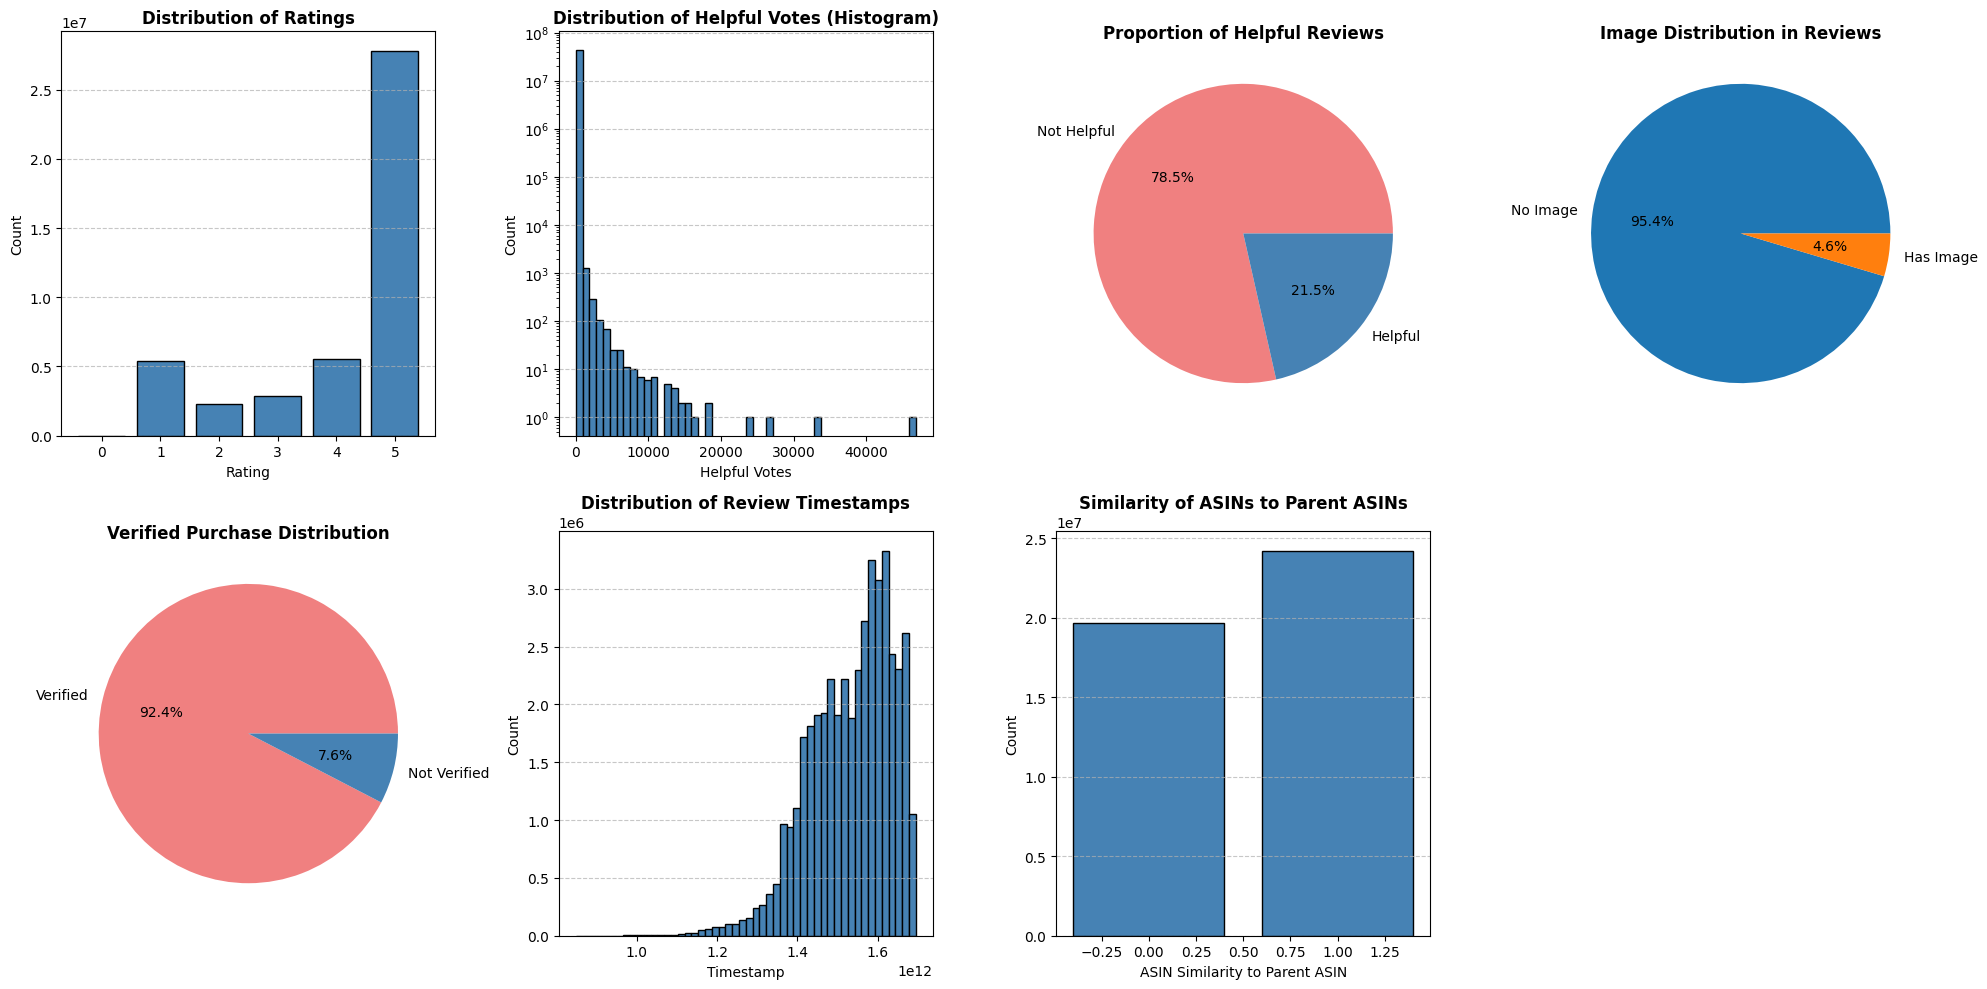

In [23]:
# Section 4: All Visualizations Combined into Subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# 1. Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Ratings', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_xticks(rating_counts.index)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Helpful Votes Histogram
axes[1].hist(df['helpful_vote'], bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Helpful Votes (Histogram)', fontweight='bold')
axes[1].set_xlabel('Helpful Votes')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Helpful Votes Pie Chart
is_helpful_review = df['helpful_vote'] > 0
counts = is_helpful_review.value_counts(sort=False).sort_index()
axes[2].pie(counts, labels=['Not Helpful', 'Helpful'], autopct='%1.1f%%', 
            colors=['lightcoral', 'steelblue'])
axes[2].set_title('Proportion of Helpful Reviews', fontweight='bold')

# 4. Image Distribution
has_image = df['images'].map(len).gt(0).value_counts()
axes[3].pie(has_image.values, 
            labels=['Has Image' if i else 'No Image' for i in has_image.index],
            autopct='%1.1f%%')
axes[3].set_title('Image Distribution in Reviews', fontweight='bold')

# 5. Verified Purchase Distribution
verified = df['verified_purchase'].value_counts()
axes[4].pie(verified.values, 
            labels=['Verified' if v else 'Not Verified' for v in verified.index],
            autopct='%1.1f%%', colors=['lightcoral', 'steelblue'])
axes[4].set_title('Verified Purchase Distribution', fontweight='bold')

# 6. Timestamp Distribution
axes[5].hist(df['timestamp'], bins=50, color='steelblue', edgecolor='black')
axes[5].set_title('Distribution of Review Timestamps', fontweight='bold')
axes[5].set_xlabel('Timestamp')
axes[5].set_ylabel('Count')
axes[5].grid(axis='y', linestyle='--', alpha=0.7)

# 7. ASIN Similarity
same_id = (df['asin'] == df['parent_asin']).value_counts().sort_index()
axes[6].bar(same_id.index, same_id.values, color='steelblue', edgecolor='black')
axes[6].set_xlabel('ASIN Similarity to Parent ASIN')
axes[6].set_ylabel('Count')
axes[6].set_title('Similarity of ASINs to Parent ASINs', fontweight='bold')
axes[6].grid(axis='y', linestyle='--', alpha=0.7)

# Hide the 8th empty subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()

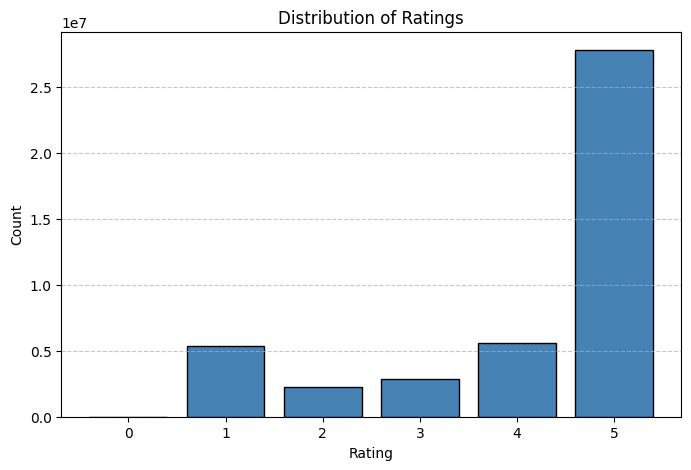


⭐ Rating Distribution:
  0.0:   0.0% 
  1.0:  12.2% ████
  2.0:   5.1% █
  3.0:   6.6% ██
  4.0:  12.7% ████
  5.0:  63.4% █████████████████████


In [24]:
# Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rating_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"\n⭐ Rating Distribution:")
for rating in sorted(df['rating'].unique()):
    count = (df['rating'] == rating).sum()
    pct = count / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f"  {rating}: {pct:5.1f}% {bar}")

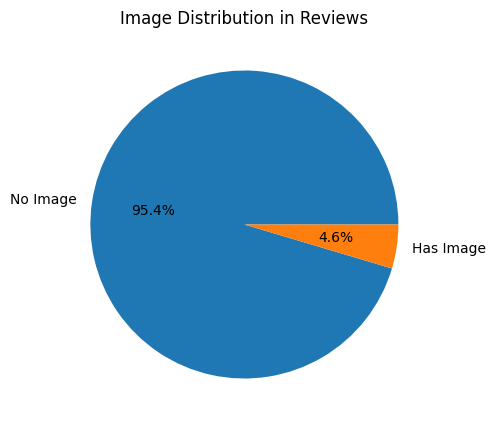


📸 Image Distribution:
  Has Image: 2,023,745 reviews (4.6%)
  No Image: 41,863,199 reviews (95.4%)


In [26]:
# Image Distribution
plt.figure(figsize=(8,5))
has_image = df['images'].map(len).gt(0).value_counts()

plt.pie(
    has_image.values,
    labels=['Has Image' if i else 'No Image' for i in has_image.index],
    autopct='%1.1f%%'
)
plt.title('Image Distribution in Reviews')
plt.show()

image_counts = (
    df["images"]
    .astype(str)
    .apply(lambda x: x != "[]" and x != "nan")
    .value_counts()
)
print(f"\n📸 Image Distribution:")
print(f"  Has Image: {image_counts.get(True, 0):,} reviews ({image_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"  No Image: {image_counts.get(False, 0):,} reviews ({image_counts.get(False, 0)/len(df)*100:.1f}%)")

# 5. Check for Missing values 

In [30]:
print("Basic Data Cleaning")

# Remove empty rows, using 'how=all' to drop rows where all the elements are missing
df = df.dropna(how='all')
print(f"  After dropping empty rows, dataset shape: {df.shape[0]:,} rows.")
print(f"  Total dropped rows: {SAMPLE_SIZE - df.shape[0]:,} ({(SAMPLE_SIZE - df.shape[0])/SAMPLE_SIZE*100:.1f}%)\n")


# Remove empty text
df = df[
    (df['text'].fillna('').str.strip().str.len() > 0) | 
    (df['title'].fillna('').str.strip().str.len() > 0)
]
print(f"  Non-Empty text or Non-Empty title, dataset shape: {df.shape[0]:,} rows.")


# Remove rows where 'text' is empty or only whitespace
print(f"  Non-empty text, dataset shape: {df[df['text'].notna() & (df['text'].str.strip().str.len() > 0)].shape[0]:,} rows.")


# Drop rows with missing text, helpful_vote, or rating
df = df.dropna(subset=["text", "helpful_vote", "rating"])
print(f"  After dropping rows with missing text, helpful_vote, or rating, dataset shape: {df.shape[0]:,} rows.")
print(f"  Total dropped rows: {df.shape[0] - df.shape[0]:,} ({(df.shape[0] - df.shape[0])/df.shape[0]*100:.1f}%)\n")

Basic Data Cleaning
  After dropping empty rows, dataset shape: 43,886,944 rows.
  Total dropped rows: -28,886,944 (-192.6%)

  Non-Empty text or Non-Empty title, dataset shape: 43,886,944 rows.
  Non-empty text, dataset shape: 43,845,751 rows.
  After dropping rows with missing text, helpful_vote, or rating, dataset shape: 43,886,944 rows.
  Total dropped rows: 0 (0.0%)



Save Raw Dataset --> To keep the raw data, if required later on

In [31]:
df_save = df.copy()

# 6. Cleaning --> According to the problem statement

## 6.1 Filter Reviews with helpful votes

In [32]:
df = df[df['helpful_vote'] > 0].copy()

print(f"  After filtering for helpful reviews, dataset shape: {df.shape[0]:,} rows.")
print(f"  Total dropped rows: {SAMPLE_SIZE - df.shape[0]:,} ({(SAMPLE_SIZE - df.shape[0])/SAMPLE_SIZE*100:.1f}%)\n")

  After filtering for helpful reviews, dataset shape: 9,421,755 rows.
  Total dropped rows: 5,578,245 (37.2%)



## 6.2 Dropping unncessary columns

**user_id**: Drop user_id because reviewer identity does not generalise to unseen users, risks data leakage and bias, and adds privacy-sensitive information with no predictive value for review helpfulness.

In [33]:
df.drop(columns=['user_id'], inplace=True)

print(f"  After dropping 'user_id' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After dropping 'user_id' column, dataset shape: 9,421,755 x 9.


**asin**: Drop asin because it represents individual product variants (colour/size versions), which fragments the data and introduces artificial duplication, whereas parent_asin already groups all variants under the true product.

**parent_asin**: Keep parent_asin because it preserves product-level context needed for business insights, clustering, and later merchant recommendations.

In [34]:
df.drop(columns=['asin'], inplace=True)

print(f"  After dropping 'asin' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After dropping 'asin' column, dataset shape: 9,421,755 x 8.


# 7. Reduce Memory Usage

In [35]:
print(f"Before dtype conversion\n{df.dtypes}")

Before dtype conversion
rating               float64
title                    str
text                     str
images                object
parent_asin              str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object


In [36]:
# Conversion of data types to optimize memory usage
dtype_mapping = {
    'rating': 'int8',
    'parent_asin': 'category',
    'helpful_vote': 'int32',
    'verified_purchase': 'bool',
}

before_mem = df.memory_usage(deep=True).sum() / 1024**2
df = df.astype(dtype_mapping)
after_mem = df.memory_usage(deep=True).sum() / 1024**2

print(f"\nMemory Usage Optimization:")
print(f"  Before optimization, memory usage: {before_mem:.2f} MB")
print(f"  After optimization, memory usage: {after_mem:.2f} MB")

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
print(f"  After converting 'timestamp' to datetime, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


Memory Usage Optimization:
  Before optimization, memory usage: 5933.25 MB
  After optimization, memory usage: 5721.79 MB
  After converting 'timestamp' to datetime, dataset shape: 9,421,755 x 8.


In [37]:
print(f"After dtype conversion\n{df.dtypes}")

After dtype conversion
rating                         int8
title                           str
text                            str
images                       object
parent_asin                category
timestamp            datetime64[ms]
helpful_vote                  int32
verified_purchase              bool
dtype: object


# 8. Feature Engineeering 

## 8.1 Merge 'text' and 'title' columns

In [38]:
# Combining text + title into single column, as some of the text are empty but title is not, and vice versa
# df['review_text'] = df
review_text = (df['title'].fillna("").str.strip() + " " + df["text"].fillna("").str.strip()).str.strip()
print(review_text.head()) 

df['review_text'] = review_text

# Check again for any empty review_text after combining
df = df[df["review_text"].str.len() > 0]
print(f"  After combining text and title, dataset shape: {df.shape[0]:,} rows.")

3     Great laptop backpack! I was searching for a s...
7     Love the headphones - great range These are fa...
12    legit legit.  love them.  I play with 1 in ful...
37    Does what it is meant to do Very easy to confi...
40    Protects my power supply from small screws Any...
dtype: str
  After combining text and title, dataset shape: 9,421,755 rows.


In [39]:
# Drop original 'text' and 'title' columns as they are now redundant
df.drop(columns=['text', 'title'], inplace=True)

print(f"  After dropping 'text' and 'title' columns, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After dropping 'text' and 'title' columns, dataset shape: 9,421,755 x 7.


## 8.2 Create new feature


| Feature | Description | Data Type |
|---|---|---|
| `review_length` | (NF) Length of review text measured in characters (proxy for textual detail) | int64 |
| `is_verified` | (NF) Indicates whether the review comes from a verified purchase | int8 |
| `image_count` | (NF) Number of images attached to the review | int16 |
| `has_image` | (NF) Binary indicator showing whether the review contains at least one image | bool |
| `days_since_first_review` | (NF) Number of days elapsed since the earliest review in the dataset (temporal normalization feature) | int32 |
| `product_popularity` | (NF) Total number of reviews associated with the product (ASIN-level activity proxy) | int32 |

In [40]:
# Create a feature for review length (number of characters) for clustering
df['review_length'] = df['review_text'].str.len().fillna(0).astype('int32')
print(f"  After adding 'review_length' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


# Convert 'verified_purchase' to int8 for clustering --> 0/1
df['is_verified'] = df['verified_purchase'].astype('int8')
if 'verified_purchase' in df.columns:
    df.drop(columns=['verified_purchase'], inplace=True)
print(f"  After converting 'verified_purchase' to 'is_verified', dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


# Create number of images and has_image features for clustering
df['image_count'] = df['images'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
).astype('int16')

df['has_image'] = (df['image_count'] > 0).astype('bool')
print(f"  After adding 'image_count' and 'has_image' columns, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


# Extract day of week and whether it's a weekend for clustering
df['day_of_week'] = df['timestamp'].dt.dayofweek.astype('int8')   # 0=Mon
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('bool')

# Create a feature for how many days since the first review in the dataset, to capture temporal trends
first_review_date = df['timestamp'].min()
df['days_since_first_review'] = (
    (df['timestamp'] - first_review_date).dt.days
    .fillna(0)
    .astype('int32')
)
print(f"  After adding temporal features, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


# Create a feature for product popularity based on the number of reviews for each parent_asin
df['product_popularity'] = (
    df.groupby('parent_asin')['parent_asin']
    .transform('count')
    .astype('int32')
)

print(f"  After adding 'product_popularity' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After adding 'review_length' column, dataset shape: 9,421,755 x 8.
  After converting 'verified_purchase' to 'is_verified', dataset shape: 9,421,755 x 8.
  After adding 'image_count' and 'has_image' columns, dataset shape: 9,421,755 x 10.
  After adding temporal features, dataset shape: 9,421,755 x 13.
  After adding 'product_popularity' column, dataset shape: 9,421,755 x 14.


In [41]:
df.head(2)

,rating,images,parent_asin,timestamp,helpful_vote,review_text,review_length,is_verified,image_count,has_image,day_of_week,is_weekend,days_since_first_review,product_popularity
3,5,[],B001OC5JKY,2010-11-20 18:41:35.000,18,Great laptop backpack! I was searching for a s...,1112,1,0,False,5,True,5115,89
7,5,[],B09S6Y5BRG,2018-11-04 18:40:31.659,9,Love the headphones - great range These are fa...,1082,1,0,False,6,True,8021,418


In [42]:
df.dtypes

rating                               int8
images                             object
parent_asin                      category
timestamp                  datetime64[ms]
helpful_vote                        int32
review_text                           str
review_length                       int32
is_verified                          int8
image_count                         int16
has_image                            bool
day_of_week                          int8
is_weekend                           bool
days_since_first_review             int32
product_popularity                  int32
dtype: object

## 8.3 Save Source of Truth

In [43]:
# Create directory if it doesn't exist
os.makedirs(DIR, exist_ok=True)

# Export the dataset
df.to_parquet(SOURCE_OF_TRUTH_FILE_PARQUET, index=False, engine="pyarrow")
print(f"Source of truth dataset exported to '{SOURCE_OF_TRUTH_FILE_PARQUET}'")

Source of truth dataset exported to '../data/processed/source_of_truth_15M.parquet'


## 8.4 Load from Scource of Truth

In [5]:
# Load from source of truth directly
if os.path.exists(SOURCE_OF_TRUTH_FILE_PARQUET):
    try:
        df = pd.read_parquet(SOURCE_OF_TRUTH_FILE_PARQUET)
        print(f"✓ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
        print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    except Exception as e:
        print(f"Error loading file: {e}")
else:
    print(f"✗ File not found: {SOURCE_OF_TRUTH_FILE_PARQUET}")
    print(f"  Expected location: {os.path.abspath(SOURCE_OF_TRUTH_FILE_PARQUET)}")

✓ Dataset loaded: 9,421,755 rows × 14 columns
  Memory usage: 6212.23 MB


# 9. Clustering

Clustering is performed to **group reviews by behavioral patterns** (rating, helpful votes, review length, verified purchase) so that when we reduce the dataset, we **retain diverse review types** and avoid losing rare but important examples. This ensures the final dataset is **representative of the original population** before sampling.

In [6]:
# Features for clustering
df_kmeans = df.copy()

Create new substitute features for KMeans to work

In [7]:
features = [
    'rating', 
    'helpful_vote', 
    'review_length', 
    'is_verified',
    'image_count',
    'has_image',
    'day_of_week',
    'is_weekend',
    'days_since_first_review',
    'product_popularity'
]

X = df_kmeans[features].copy()
print(f"Dataframe for clustering: \n{X.head(2)}")

Dataframe for clustering: 
   rating  helpful_vote  review_length  is_verified  image_count  has_image  \
0       5            18           1112            1            0      False   
1       5             9           1082            1            0      False   

   day_of_week  is_weekend  days_since_first_review  product_popularity  
0            5        True                     5115                  89  
1            6        True                     8021                 418  


In [8]:
# Stardardiz the features for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
inertia = []
sil_scores = []
k_range = range(2, 15)

for k in k_range:
    print(f"Running KMeans for k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)

    sample_idx = np.random.choice(len(X_scaled), 100_000, replace=False)
    X_sample = X_scaled[sample_idx]
    labels_sample = labels[sample_idx]

    sil_score = silhouette_score(X_sample, labels_sample)
    sil_scores.append(sil_score)

    print(f"  Inertia for {k} clusters: {inertia[-1]:.2f}")
    print(f"  Silhouette Score for {k} clusters: {sil_score:.4f}")

Running KMeans for k=2...
  Inertia for 2 clusters: 83566573.59
  Silhouette Score for 2 clusters: 0.3514
Running KMeans for k=3...
  Inertia for 3 clusters: 70194506.63
  Silhouette Score for 3 clusters: 0.3056
Running KMeans for k=4...
  Inertia for 4 clusters: 57620921.69
  Silhouette Score for 4 clusters: 0.3465
Running KMeans for k=5...
  Inertia for 5 clusters: 50812910.46
  Silhouette Score for 5 clusters: 0.3556
Running KMeans for k=6...
  Inertia for 6 clusters: 47384401.69
  Silhouette Score for 6 clusters: 0.3649
Running KMeans for k=7...
  Inertia for 7 clusters: 42591749.12
  Silhouette Score for 7 clusters: 0.3136
Running KMeans for k=8...
  Inertia for 8 clusters: 40031927.39
  Silhouette Score for 8 clusters: 0.3187
Running KMeans for k=9...
  Inertia for 9 clusters: 36156746.55
  Silhouette Score for 9 clusters: 0.3183
Running KMeans for k=10...
  Inertia for 10 clusters: 33849638.78
  Silhouette Score for 10 clusters: 0.2849
Running KMeans for k=11...
  Inertia for 11

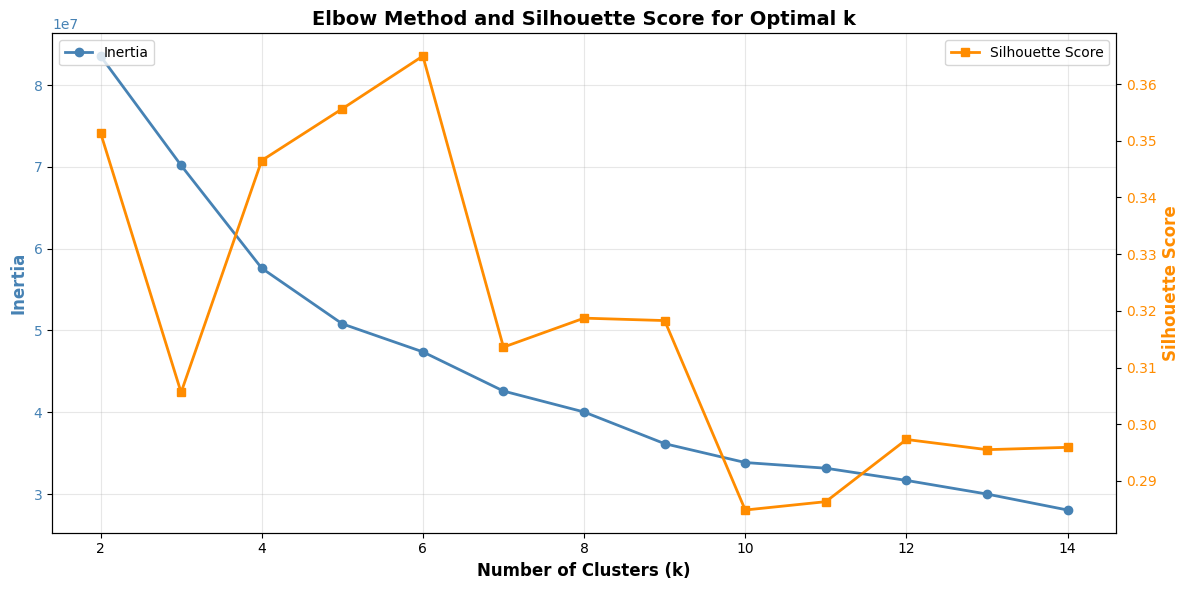

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Elbow Curve on left y-axis
ax1.plot(k_range, inertia, 'o-', color='steelblue', linewidth=2, markersize=6, label='Inertia')
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Inertia', color='steelblue', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(True, alpha=0.3)

# Create second y-axis for Silhouette Score using twinx()
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 's-', color='darkorange', linewidth=2, markersize=6, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='darkorange', fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Title and legends
plt.title('Elbow Method and Silhouette Score for Optimal k', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Although k=6 has a slightly higher silhouette score, the improvement over k=5 is marginal, and selecting k=5 respects the elbow principle by balancing cluster quality with model simplicity and interpretability.

In [14]:
# num_clusters = int(input("Based on the Elbow and Silhouette analysis, enter the optimal number of clusters (k): "))
num_clusters = 6

kmeans = KMeans(n_clusters=num_clusters, random_state=RANDOM_STATE)
df_kmeans['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

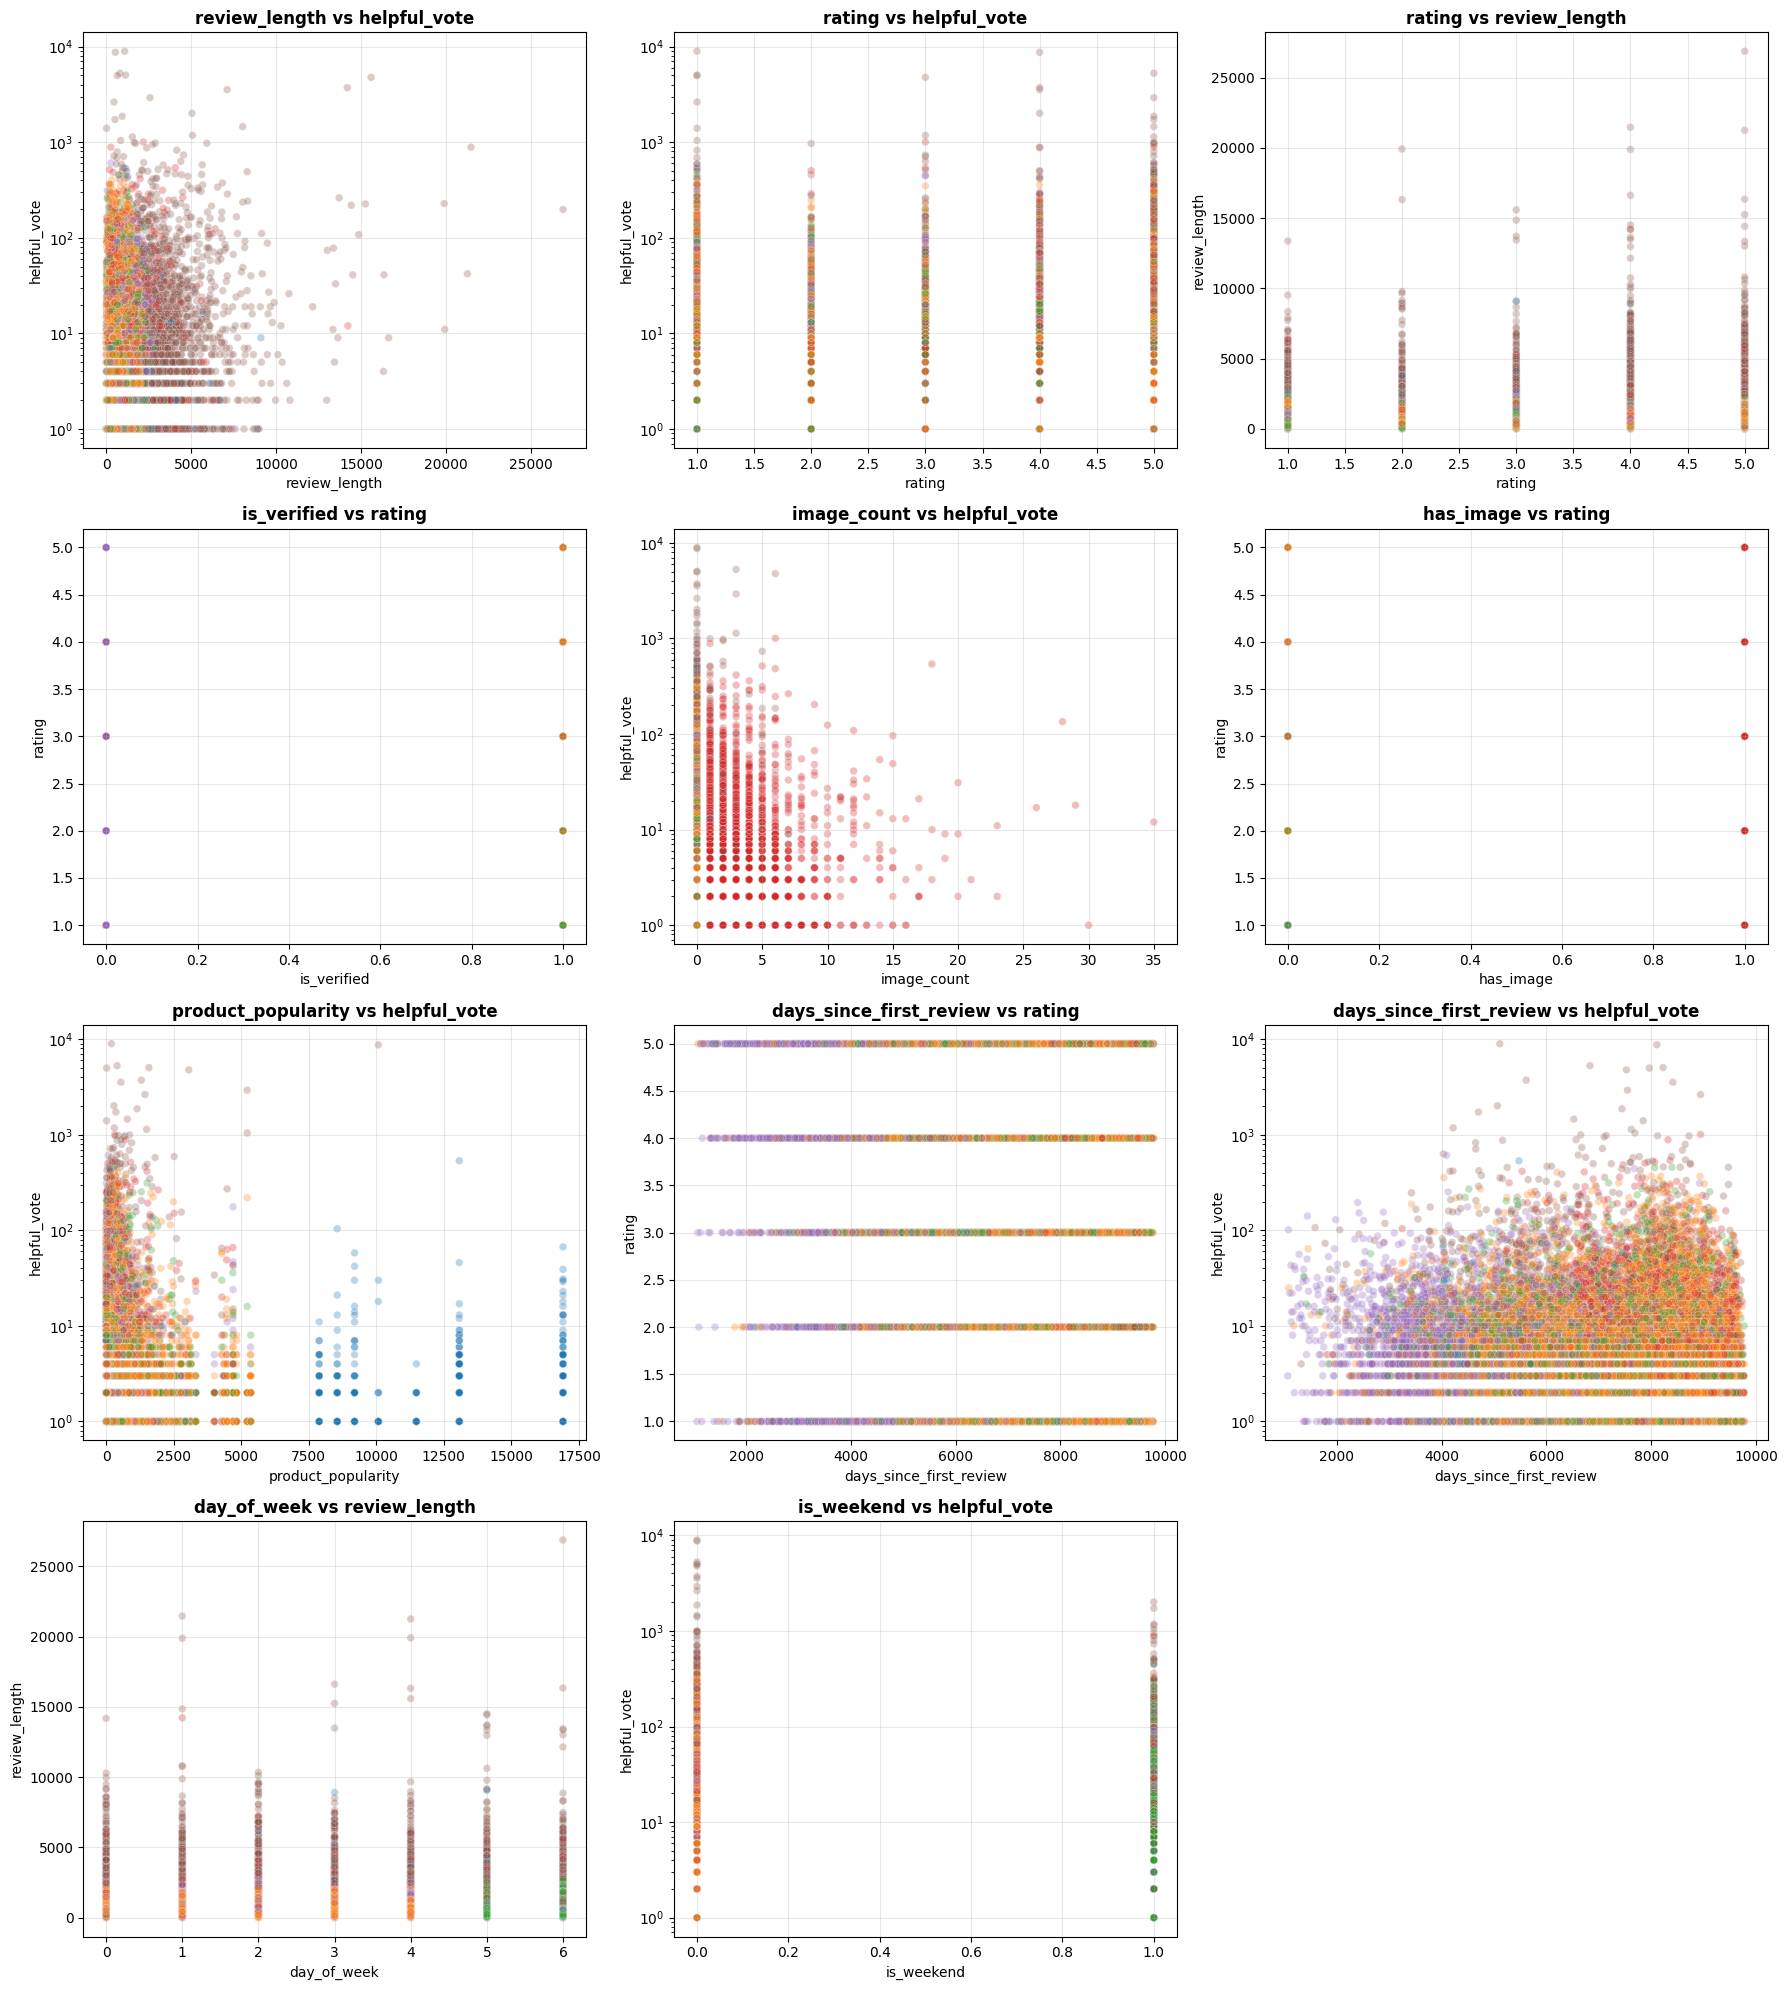

In [15]:
viz_df = df_kmeans.sample(n=100_000, random_state=RANDOM_STATE)

feature_pairs = [
    ('review_length', 'helpful_vote'),
    ('rating', 'helpful_vote'),
    ('rating', 'review_length'),
    # ('verified_purchase', 'rating'),
    ('is_verified', 'rating'),
    ('image_count', 'helpful_vote'),
    ('has_image', 'rating'),
    ('product_popularity', 'helpful_vote'),
    ('days_since_first_review', 'rating'),
    ('days_since_first_review', 'helpful_vote'),
    ('day_of_week', 'review_length'),
    ('is_weekend', 'helpful_vote')
]

rows = 4
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(18, 20))
axes = axes.flatten()

for i, (x_feat, y_feat) in enumerate(feature_pairs):
    sns.scatterplot(
        data=viz_df,
        x=x_feat,
        y=y_feat,
        hue='cluster_kmeans',
        palette='tab10',
        alpha=0.3,
        s=30,
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f"{x_feat} vs {y_feat}", fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    
    if y_feat == 'helpful_vote':
        axes[i].set_yscale('log') # Stretches the '0 to 1000' range

# Remove empty subplot if exists
for j in range(len(feature_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Text(0.5, 0, 'PCA Component 3')

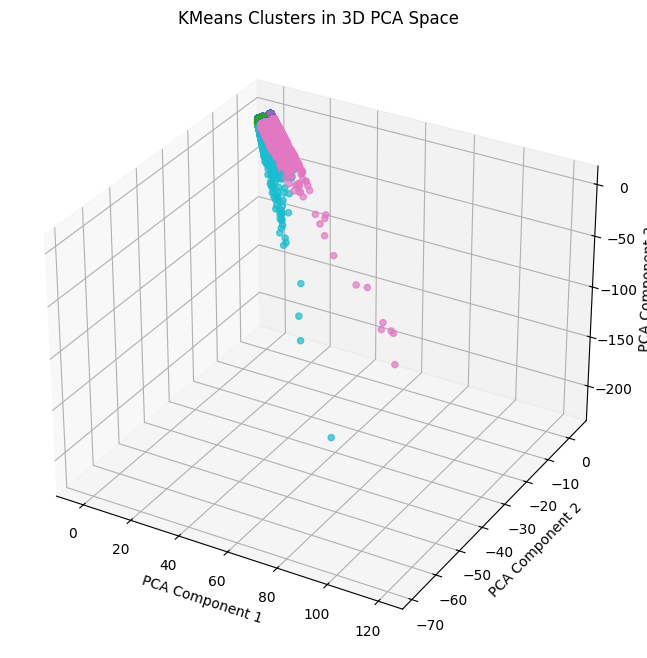

In [16]:
pca3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca3d.fit_transform(X_scaled)


# 3D Scatter Plot of PCA Components colored by KMeans clusters
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c = df_kmeans['cluster_kmeans'],
    cmap = 'tab10',
    s = 20,
    alpha = 0.7
)

ax.set_title('KMeans Clusters in 3D PCA Space')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

In [17]:
# CLUSTER PORTFOLIO / PROFILE

# Number of samples per cluster
cluster_size = df_kmeans.groupby('cluster_kmeans').size().rename("count")

# Percentage share of each cluster
cluster_percentage = (
    df_kmeans['cluster_kmeans']
    .value_counts(normalize=True)
    .sort_index() * 100
).rename("percentage")

# Behavioural statistics per cluster
cluster_profile = df_kmeans.groupby('cluster_kmeans').agg({
    'rating': ['mean', 'median'],
    'helpful_vote': ['mean', 'median', 'max'],
    'review_length': ['mean', 'median'],
    'is_verified': 'mean',
    'image_count': ['mean', 'median', 'max'],
    'has_image': 'mean',
    'day_of_week': ['mean', 'median'],
    'is_weekend': 'mean',
    'days_since_first_review': ['mean', 'median'],
    'product_popularity': ['mean', 'median', 'max']
})

# Combine everything
cluster_portfolio = pd.concat(
    [cluster_size, cluster_percentage, cluster_profile],
    axis=1
)

cluster_portfolio

,count,percentage,"(rating, mean)","(rating, median)","(helpful_vote, mean)","(helpful_vote, median)","(helpful_vote, max)","(review_length, mean)","(review_length, median)","(is_verified, mean)",...,"(image_count, max)","(has_image, mean)","(day_of_week, mean)","(day_of_week, median)","(is_weekend, mean)","(days_since_first_review, mean)","(days_since_first_review, median)","(product_popularity, mean)","(product_popularity, median)","(product_popularity, max)"
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
0,77022,0.817491,3.784360,5.0,3.338345,1.0,3490,512.043611,275.0,0.934123,...,12,0.015723,2.955844,3.0,0.284425,7080.509712,7342.0,11798.093934,11482.0,16910
1,5489347,58.262468,3.687547,5.0,3.450975,1.0,688,403.944282,278.0,1.000000,...,0,0.000000,1.975682,2.0,0.000000,7659.499709,7738.0,242.977526,57.0,5354
2,1910848,20.281232,3.676877,5.0,3.548305,1.0,775,414.031838,278.0,0.999998,...,0,0.000000,5.490765,5.0,1.000000,7684.169575,7790.0,247.690358,58.0,5354
3,822041,8.724924,3.944010,5.0,8.095332,2.0,1379,611.328614,401.0,0.887407,...,168,1.000000,2.935708,3.0,0.269171,8420.833038,8647.0,163.177217,42.0,9195
4,930347,9.874455,3.381818,4.0,5.242712,2.0,814,718.341232,540.0,0.000000,...,1,0.001045,2.885873,3.0,0.256313,6307.797203,6452.0,218.603327,45.0,5354
5,192150,2.039429,3.860682,4.0,53.803294,6.0,46841,3843.515519,3282.0,0.707047,...,27,0.059495,2.826698,3.0,0.225215,6596.646563,6527.0,287.197871,80.0,16910


# 10. Sampling

Sampling by a single feature like rating or parent_asin preserves only one dimension of the data distribution, while real review behaviour depends on multiple interacting factors (rating, helpfulness, review length, purchase verification).
Cluster-based sampling captures these multivariate behavioural patterns simultaneously instead of enforcing artificial balance along one column.
Therefore, clustering maintains the natural joint structure of the dataset rather than oversimplifying representativeness to a single feature.

In [18]:
SAMPLED_FRACTION = 0.1

While the paper’s deterministic uniformity minimizes variance for structural reliability, our use of stratified random sampling ensures the dataset retains the "stochastic noise" and "edge cases" necessary for a robust AI model. By capturing these rare, unique points within each cluster, we may see lower metrics during training, but we ensure the model generalizes better to the messy, unpredictable nature of real-world consumer data.

**Paper:**\
Song, J. and Xu, J. (2024) ‘A clustering-based partially stratified sampling for high-dimensional structural reliability assessment’, Computers and Structures, 299, 107390. doi: 10.1016/j.compstruc.2024.107390.

In [19]:
sampled_df = (
    df_kmeans
    .groupby('cluster_kmeans', as_index=False)
    .sample(frac=SAMPLED_FRACTION, random_state=RANDOM_STATE)
)

# Check the dtypes of the sampled dataframe
print(f"Dtypes in sampled dataframe: \n{sampled_df.dtypes}")
print(f"Sampled dataframe shape: {sampled_df.shape}")

Dtypes in sampled dataframe: 
rating                               int8
images                             object
parent_asin                      category
timestamp                  datetime64[ms]
helpful_vote                        int32
review_text                           str
review_length                       int32
is_verified                          int8
image_count                         int16
has_image                            bool
day_of_week                          int8
is_weekend                           bool
days_since_first_review             int32
product_popularity                  int32
cluster_kmeans                      int32
dtype: object
Sampled dataframe shape: (942176, 15)


In [20]:
print("Original size:", len(df_kmeans))
print("Sampled size:", len(sampled_df))

print("\nOriginal cluster distribution:")
print(df_kmeans['cluster_kmeans'].value_counts(normalize=True))

print("\nSampled cluster distribution:")
print(sampled_df['cluster_kmeans'].value_counts(normalize=True))

Original size: 9421755
Sampled size: 942176

Original cluster distribution:
cluster_kmeans
1    0.582625
2    0.202812
4    0.098745
3    0.087249
5    0.020394
0    0.008175
Name: proportion, dtype: float64

Sampled cluster distribution:
cluster_kmeans
1    0.582625
2    0.202812
4    0.098745
3    0.087249
5    0.020394
0    0.008175
Name: proportion, dtype: float64


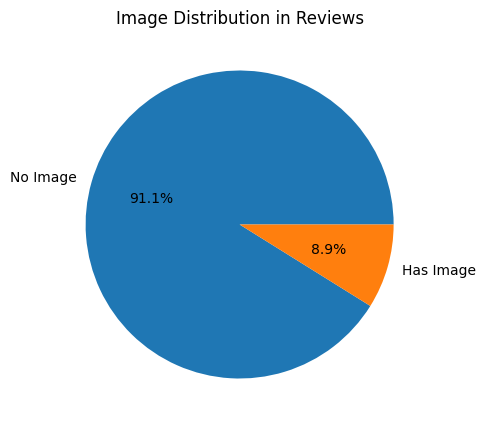


📸 Image Distribution:
  Has Image: 83,577 reviews (8.9%)
  No Image: 858,599 reviews (91.1%)


In [28]:
# Image Distribution
plt.figure(figsize=(8,5))
has_image = sampled_df['images'].map(len).gt(0).value_counts()

plt.pie(
    has_image.values,
    labels=['Has Image' if i else 'No Image' for i in has_image.index],
    autopct='%1.1f%%'
)
plt.title('Image Distribution in Reviews')
plt.show()

image_counts = (
    sampled_df["images"]
    .astype(str)
    .apply(lambda x: x != "[]" and x != "nan")
    .value_counts()
)
print(f"\n📸 Image Distribution:")
print(f"  Has Image: {image_counts.get(True, 0):,} reviews ({image_counts.get(True, 0)/len(sampled_df)*100:.1f}%)")
print(f"  No Image: {image_counts.get(False, 0):,} reviews ({image_counts.get(False, 0)/len(sampled_df)*100:.1f}%)")

# 11. Export as Praquet 

**📚 Understanding Parquet Format** 

The following resources helped in understanding **why Parquet is used for dataset export**.  

- [What is Parquet? (YouTube)](https://youtu.be/KLFadWdomyI?si=4RM2NXcPo147rxec)
- [Parquet Explained — Short Overview](https://youtube.com/shorts/-f8rs4A_MHA?si=6-XsfKYL3jbt_zy3)

These videos provide a quick conceptual understanding of columnar storage and performance advantages relevant to our pipeline.

**Why Use Parquet Format**

- Columnar storage format → significantly smaller file size than CSV  
- Faster read and write performance for large datasets  
- More memory-efficient loading during analysis and modelling  
- Requires no database server or configuration  
- Loads instantly into pandas, Spark, and ML pipelines  
- Preserves datatypes natively (no re-parsing needed)  
- Avoids schema loss and datatype inconsistencies common in CSV files

In [22]:
print(f"Dataset shape before export: {sampled_df.shape[0]:,} rows x {sampled_df.shape[1]:,} columns")
print(f"Memory usage before export: {sampled_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("Dataset preview before export:")
sampled_df.head(2)

Dataset shape before export: 942,176 rows x 15 columns
Memory usage before export: 644.45 MB
Dataset preview before export:


,rating,images,parent_asin,timestamp,helpful_vote,review_text,review_length,is_verified,image_count,has_image,day_of_week,is_weekend,days_since_first_review,product_popularity,cluster_kmeans
1867610,5,[],B0051VVOB2,2012-01-28 13:35:06,3,Kindle Fire Initially I had trouble using the ...,1832,1,0,False,5,True,5548,13072,0
3497589,5,[],B010BWYDYA,2008-11-26 16:11:05,2,I'm amazed This is my first experience with an...,445,1,0,False,2,False,4390,16910,0


In [23]:
dropped_features = [ 
    'verified_purchase',
    'day_of_week',
    'is_weekend',
    'cluster_kmeans'
]

for feature in dropped_features:
    if feature in sampled_df.columns:
        sampled_df.drop(columns=[feature], inplace=True)

print(f"\nDataset shape after dropping features: {sampled_df.shape[0]:,} rows x {sampled_df.shape[1]:,} columns")


Dataset shape after dropping features: 942,176 rows x 12 columns


In [24]:
# Create directory if it doesn't exist
os.makedirs(DIR, exist_ok=True)

# Export the dataset
sampled_df.to_parquet(SAMPLED_PARQUET, index=False, engine="pyarrow")
print(f"Sampled dataset exported to '{SAMPLED_PARQUET}'")

Sampled dataset exported to '../data/processed/amazon_reviews_s10.parquet'


In [25]:
# Export as CSV for size comparison
sampled_df.to_csv(SAMPLED_CSV, index=False)
print(f"Sampled dataset exported to '{SAMPLED_CSV}'")

Sampled dataset exported to '../data/processed/amazon_reviews_s10.csv'


In [26]:
parquet_size = os.path.getsize(SAMPLED_PARQUET) / 1024**2
csv_size = os.path.getsize(SAMPLED_CSV) / 1024**2

print(f"Parquet size: {parquet_size:.2f} MB")
print(f"CSV size: {csv_size:.2f} MB")
print(f"Compression gain: {csv_size / parquet_size:.2f}x smaller")

Parquet size: 318.35 MB
CSV size: 584.27 MB
Compression gain: 1.84x smaller


In [ ]:
# # Delete CSV file (keep only Parquet as source of truth)
# if os.path.exists(SAMPLED_CSV):
#     os.remove(SAMPLED_CSV)
#     print(f"CSV file deleted: '{SAMPLED_CSV}'")
# else:
#     print(f"CSV file not found: '{SAMPLED_CSV}'")

CSV file deleted: '../data/processed/amazon_reviews_s30.csv'


## Data Dictionary — Source of Truth Features

| Feature | Description | Data Type |
|---|---|---|
| `rating` | Star rating given by the reviewer (1–5 scale) | int8 |
| `helpful_vote` | Number of users who marked the review as helpful | int32 |
| `review_text` | Raw textual content of the review | str |
| `review_length` | (NF) Length of review text measured in characters (proxy for textual detail) | int64 |
| `is_verified` | (NF) Indicates whether the review comes from a verified purchase | int8 |
| `images` | List containing image metadata or image references associated with the review | object |
| `image_count` | (NF) Number of images attached to the review | int16 |
| `has_image` | (NF) Binary indicator showing whether the review contains at least one image | bool |
| `timestamp` | Date and time when the review was posted | datetime64[ms] |
| `days_since_first_review` | (NF) Number of days elapsed since the earliest review in the dataset (temporal normalization feature) | int32 |
| `parent_asin` | Unique identifier representing the reviewed product | category |
| `product_popularity` | (NF) Total number of reviews associated with the product (ASIN-level activity proxy) | int32 |